# Notebook 14 — Location Classification: EfficientNet-B0 Training & Evaluation

**Task ID:** LOC-EFF-001  
**Phase:** 11b — Damaged-Part Location CNN (EfficientNet-B0)  
**Owner:** Detection ML Member / Antigravity  
**Dataset:** COCO Car Damage Detection Dataset (59 train / 11 val / 8 test images)  
**Date:** 2026-09-22  
**Environment:** Google Colab (GPU recommended)

## Purpose

Train an **EfficientNet-B0 image-level classifier** to predict which vehicle part is visibly damaged.  
This notebook uses the **same dataset, same label derivation, and same evaluation protocol** as Notebook 13  
(MobileNetV2) so that results are directly comparable in Notebook 15.

| Class ID | Part Name |
|---|---|
| 0 | headlamp |
| 1 | front_bumper |
| 2 | hood |
| 3 | door |
| 4 | rear_bumper |

## Hypothesis

EfficientNet-B0, with its compound scaling and superior feature extraction (≥MobileNetV2 on ImageNet),  
will achieve higher macro F1 than MobileNetV2 on this 5-class location task.

> **Dataset Handling Note:**
> Identical to Notebook 13, `load_location_splits()` pools available annotated images and constructs a
> stratified 80/20 train/val split (48 train / 12 val) ensuring every class is represented in validation.


In [17]:
# Cell 1 — Environment, seeds, versions (identical to Notebook 13 for reproducibility)
import os, sys, random, importlib
from pathlib import Path
import numpy as np
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IN_COLAB = 'google.colab' in sys.modules
try:
    import google.colab; IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    COLAB_BASE = Path('/content/NPN-Car-Insurance')
    if not COLAB_BASE.exists():
        import subprocess
        subprocess.run(['git', 'clone', 'https://github.com/AmitavaDatta2004/NPN-Car-Insurance.git', str(COLAB_BASE)], check=True)
    REPO_ROOT = COLAB_BASE
else:
    REPO_ROOT = Path.cwd()
    while not (REPO_ROOT / 'ml').exists() and REPO_ROOT != REPO_ROOT.parent:
        REPO_ROOT = REPO_ROOT.parent

ML_SRC = REPO_ROOT / 'ml' / 'src'
if str(ML_SRC) not in sys.path:
    sys.path.insert(0, str(ML_SRC))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device} | Seed: {SEED} | Repo: {REPO_ROOT}')
for pkg in ['torch', 'torchvision', 'timm', 'numpy']:
    try:
        mod = importlib.import_module(pkg)
        print(f'  {pkg:<15} {getattr(mod, "__version__", "unknown")}')
    except ImportError:
        print(f'  {pkg:<15} NOT INSTALLED')


Device: cuda | Seed: 42 | Repo: /content/NPN-Car-Insurance
  torch           2.11.0+cu128
  torchvision     0.26.0+cu128
  timm            1.0.29
  numpy           2.1.3


In [18]:
# Cell 2 — Locate raw COCO dataset and audit physical files on disk
from pathlib import Path
from claimvision_ml.location.dataset import LOCATION_CLASSES

RAW_CANDIDATES = [
    REPO_ROOT / 'data' / 'raw' / 'coco_car_damage' / 'coco-car-damage-detection-dataset' / 'coco-car-damage-detection-dataset',
    REPO_ROOT / 'data' / 'raw' / 'coco_car_damage' / 'coco-car-damage-detection-dataset',
    REPO_ROOT / 'data' / 'raw' / 'coco_car_damage',
    Path('/content/NPN-Car-Insurance/data/raw/coco_car_damage/coco-car-damage-detection-dataset/coco-car-damage-detection-dataset'),
    Path('/content/data/raw/coco_car_damage/coco-car-damage-detection-dataset/coco-car-damage-detection-dataset'),
]
RAW_DIR = None
for c in RAW_CANDIDATES:
    if (c / 'train').exists() and (c / 'val').exists():
        RAW_DIR = c; break
if RAW_DIR is None:
    raise RuntimeError('COCO raw dataset not found. Run Notebook 00 first.')
print(f'RAW_DIR: {RAW_DIR}\n')

print('=== Raw Physical Disk Audit ===')
for s in ['train', 'val', 'test']:
    sdir = RAW_DIR / s
    if sdir.exists():
        imgs = [f for f in sdir.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
        annos = list(sdir.glob('*.json'))
        print(f'  [{s:<5}] {len(imgs):>2} physical image files on disk, {len(annos)} JSON annotation files')


RAW_DIR: /content/NPN-Car-Insurance/data/raw/coco_car_damage/coco-car-damage-detection-dataset/coco-car-damage-detection-dataset

=== Raw Physical Disk Audit ===
  [train] 59 physical image files on disk, 2 JSON annotation files
  [val  ]  1 physical image files on disk, 2 JSON annotation files
  [test ]  8 physical image files on disk, 0 JSON annotation files


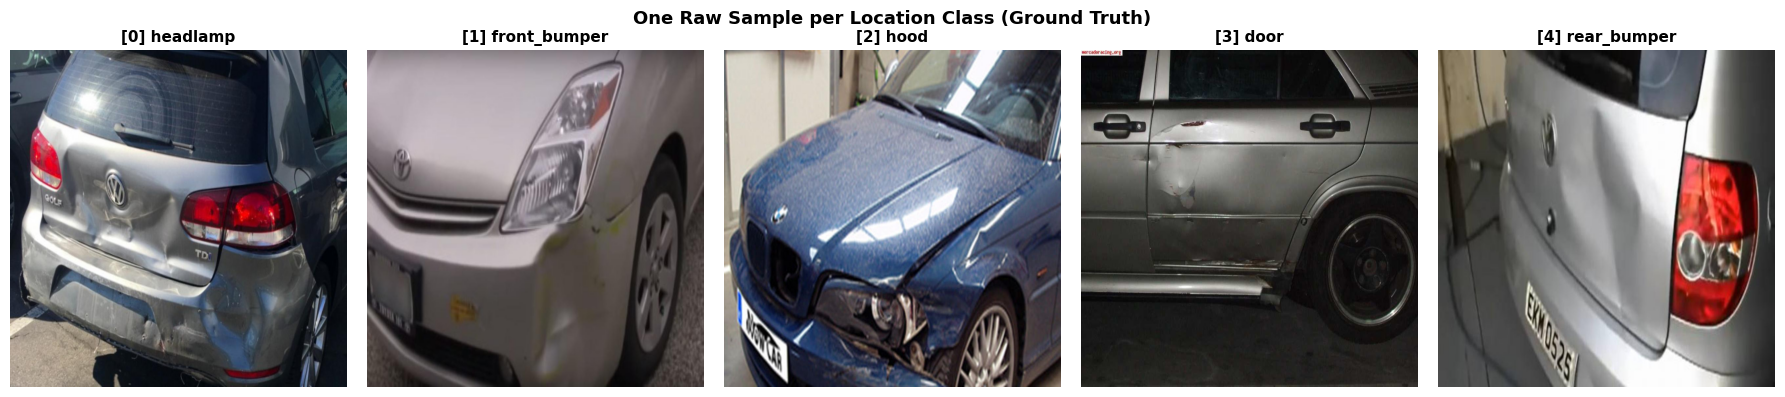

In [19]:
# Cell 3 — Sample image grid per class (same images as NB 13 for direct comparison)
import cv2, matplotlib.pyplot as plt
from claimvision_ml.location.dataset import derive_location_labels

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
shown = {cls: False for cls in LOCATION_CLASSES}
train_anno_path = RAW_DIR / 'train' / 'COCO_mul_train_annos.json'
train_lmap = derive_location_labels(train_anno_path) if train_anno_path.exists() else {}

for fname, (label_id, label_name) in train_lmap.items():
    if shown[label_name]: continue
    img = cv2.imread(str(RAW_DIR / 'train' / fname))
    if img is None: continue
    axes[label_id].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[label_id].set_title(f'[{label_id}] {label_name}', fontsize=11, fontweight='bold')
    axes[label_id].axis('off'); shown[label_name] = True
    if all(shown.values()): break
plt.suptitle('One Raw Sample per Location Class (Ground Truth)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [20]:
# Cell 4 — EfficientNet-B0 Architecture Summary
from claimvision_ml.location.efficientnet import build_location_efficientnet

model = build_location_efficientnet(dropout=0.3, num_classes=5, pretrained=True).to(device)
counts = model.parameter_count()
print('=== Location EfficientNet-B0 Architecture Summary ===')
print(f'Backbone      : EfficientNet-B0 via timm (ImageNet pretrained)')
print(f'Input Size    : 224 × 224 × 3 RGB')
print(f'Head          : Dropout → Linear(1280→128) → ReLU → Dropout → Linear(128→5)')
print(f'Classes (nc)  : 5 — {LOCATION_CLASSES}')
print(f'Device        : {device}')
print()
print(f'Total params  : {counts["total"]:,}')
print(f'Trainable     : {counts["trainable"]:,}  (Stage A: head only)')
print(f'Frozen        : {counts["frozen"]:,}')


=== Location EfficientNet-B0 Architecture Summary ===
Backbone      : EfficientNet-B0 via timm (ImageNet pretrained)
Input Size    : 224 × 224 × 3 RGB
Head          : Dropout → Linear(1280→128) → ReLU → Dropout → Linear(128→5)
Classes (nc)  : 5 — ['headlamp', 'front_bumper', 'hood', 'door', 'rear_bumper']
Device        : cuda

Total params  : 4,172,161
Trainable     : 164,613  (Stage A: head only)
Frozen        : 4,007,548


In [21]:
# Cell 5 — Dataset and DataLoader (same stratified split as NB 13)
from torch.utils.data import DataLoader
from claimvision_ml.location.dataset import load_location_splits

BATCH_SIZE = 8; NUM_WORKERS = 0

train_ds, val_ds = load_location_splits(RAW_DIR, val_ratio=0.20, seed=SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print('=== Split Construction Summary ===')
print(repr(train_ds))
print(repr(val_ds))
print(f'\nTrain batches : {len(train_loader)} ({len(train_ds)} samples)')
print(f'Val batches   : {len(val_loader)} ({len(val_ds)} samples)')

print('\nPer-class breakdown in validation set:')
val_counts = val_ds.label_counts
for cid, cname in enumerate(LOCATION_CLASSES):
    print(f'  [{cid}] {cname:<16}: {val_counts.get(cid, 0):>2} images')

class_weights = train_ds.class_weights().to(device)
print(f'\nNormalized class weights: {[round(w, 3) for w in class_weights.tolist()]}')


=== Split Construction Summary ===
LocationDataset(split='train', n=48, headlamp=13, front_bumper=14, hood=2, door=7, rear_bumper=12)
LocationDataset(split='val', n=12, headlamp=4, front_bumper=3, hood=0, door=2, rear_bumper=3)

Train batches : 6 (48 samples)
Val batches   : 2 (12 samples)

Per-class breakdown in validation set:
  [0] headlamp        :  4 images
  [1] front_bumper    :  3 images
  [2] hood            :  0 images
  [3] door            :  2 images
  [4] rear_bumper     :  3 images

Normalized class weights: [0.44, 0.408, 2.859, 0.817, 0.476]


In [22]:
# Cell 6 — Stage A: Train classification head (EfficientNet backbone frozen)
import torch.nn as nn, torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

STAGE_A_EPOCHS = 25; STAGE_A_LR = 1e-3; PATIENCE = 12

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=STAGE_A_LR, weight_decay=1e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=STAGE_A_EPOCHS, eta_min=1e-5)

output_dir = REPO_ROOT / 'ml' / 'results' / 'location'
output_dir.mkdir(parents=True, exist_ok=True)
best_ckpt  = output_dir / 'location_efficientnet_best.pt'

history_a  = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = -1.0
best_val_loss = float('inf')
patience_count = 0

print(f'Stage A — Training head for up to {STAGE_A_EPOCHS} epochs')
for epoch in range(1, STAGE_A_EPOCHS + 1):
    model.train(); train_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad(); loss = criterion(model(imgs), labels); loss.backward(); optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_loader.dataset)
    model.eval(); val_loss = correct = total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device); logits = model(imgs)
            val_loss += criterion(logits, labels).item() * imgs.size(0)
            correct += (logits.argmax(1) == labels).sum().item(); total += imgs.size(0)
    val_loss /= len(val_loader.dataset); val_acc = correct / total
    history_a['train_loss'].append(train_loss); history_a['val_loss'].append(val_loss); history_a['val_acc'].append(val_acc)
    scheduler.step()

    if epoch == 1 or val_acc > best_val_acc or (val_acc == best_val_acc and val_loss < best_val_loss):
        best_val_acc = val_acc; best_val_loss = val_loss; patience_count = 0
        torch.save(model.state_dict(), best_ckpt)
    else:
        patience_count += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{STAGE_A_EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Acc: {val_acc:.3f} (Best: {best_val_acc:.3f})')
    if patience_count >= PATIENCE: print(f'Early stop epoch {epoch}'); break
print(f'Stage A complete. Best val acc: {best_val_acc:.4f} (Val Loss: {best_val_loss:.4f})')


Stage A — Training head for up to 25 epochs
Epoch   1/25 | Train: 1.6162 | Val: 1.5307 | Acc: 0.333 (Best: 0.333)
Epoch   5/25 | Train: 1.2602 | Val: 1.4019 | Acc: 0.500 (Best: 0.500)
Epoch  10/25 | Train: 0.7725 | Val: 1.1926 | Acc: 0.667 (Best: 0.667)
Epoch  15/25 | Train: 0.6968 | Val: 1.1272 | Acc: 0.583 (Best: 0.750)
Epoch  20/25 | Train: 0.5455 | Val: 1.1215 | Acc: 0.583 (Best: 0.750)
Epoch  25/25 | Train: 0.5280 | Val: 1.1239 | Acc: 0.583 (Best: 0.750)
Stage A complete. Best val acc: 0.7500 (Val Loss: 1.0944)


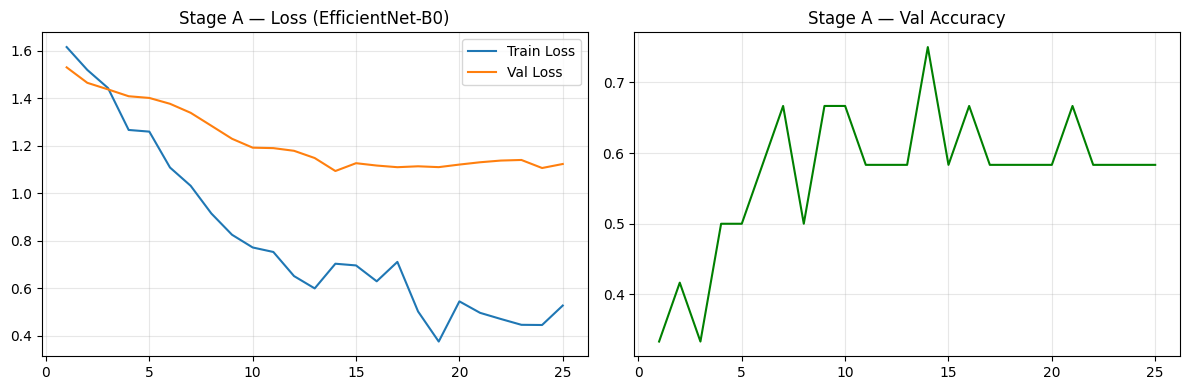

In [23]:
# Cell 7 — Stage A Training Curves
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
e = range(1, len(history_a['train_loss'])+1)
axes[0].plot(e, history_a['train_loss'], label='Train Loss'); axes[0].plot(e, history_a['val_loss'], label='Val Loss')
axes[0].set_title('Stage A — Loss (EfficientNet-B0)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(e, history_a['val_acc'], color='green'); axes[1].set_title('Stage A — Val Accuracy'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(output_dir / 'location_efficientnet_stage_a_curves.png', dpi=200); plt.show()


In [24]:
# Cell 8 — Stage B: Unfreeze last 2 EfficientNet blocks and fine-tune
STAGE_B_EPOCHS = 15; STAGE_B_LR = 5e-5; PATIENCE_B = 10

model = model.to(device)
model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))
model = model.to(device)
model.unfreeze_last_blocks(n_blocks=2)
model = model.to(device)
print(f'Stage B trainable params: {model.parameter_count()["trainable"]:,}')
optimizer_b = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=STAGE_B_LR, weight_decay=1e-4)
scheduler_b = CosineAnnealingLR(optimizer_b, T_max=STAGE_B_EPOCHS, eta_min=1e-6)

history_b = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_b_acc = best_val_acc
best_b_loss = best_val_loss
patience_count_b = 0

for epoch in range(1, STAGE_B_EPOCHS + 1):
    model.train(); train_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_b.zero_grad()
        logits = model(imgs); loss = criterion(logits, labels)
        loss.backward(); optimizer_b.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval(); val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            val_loss += criterion(logits, labels).item() * imgs.size(0)
            correct += (logits.argmax(1) == labels).sum().item(); total += imgs.size(0)
    val_loss /= len(val_loader.dataset); val_acc = correct / total

    history_b['train_loss'].append(train_loss)
    history_b['val_loss'].append(val_loss)
    history_b['val_acc'].append(val_acc)
    scheduler_b.step()

    if val_acc > best_b_acc or (val_acc == best_b_acc and val_loss < best_b_loss):
        best_b_acc = val_acc; best_b_loss = val_loss; patience_count_b = 0
        torch.save(model.state_dict(), best_ckpt)
    else:
        patience_count_b += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{STAGE_B_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} (Best: {best_b_acc:.3f})')
    if patience_count_b >= PATIENCE_B:
        print(f'Early stopping at epoch {epoch}'); break

print(f'\nStage B complete. Best val accuracy: {best_b_acc:.4f}')


Stage B trainable params: 3,320,353
Epoch   1/15 | Train Loss: 0.5839 | Val Loss: 1.0933 | Val Acc: 0.750 (Best: 0.750)
Epoch   5/15 | Train Loss: 0.3939 | Val Loss: 1.0610 | Val Acc: 0.667 (Best: 0.750)
Epoch  10/15 | Train Loss: 0.4089 | Val Loss: 0.9852 | Val Acc: 0.750 (Best: 0.750)
Epoch  15/15 | Train Loss: 0.3398 | Val Loss: 1.0195 | Val Acc: 0.667 (Best: 0.750)

Stage B complete. Best val accuracy: 0.7500


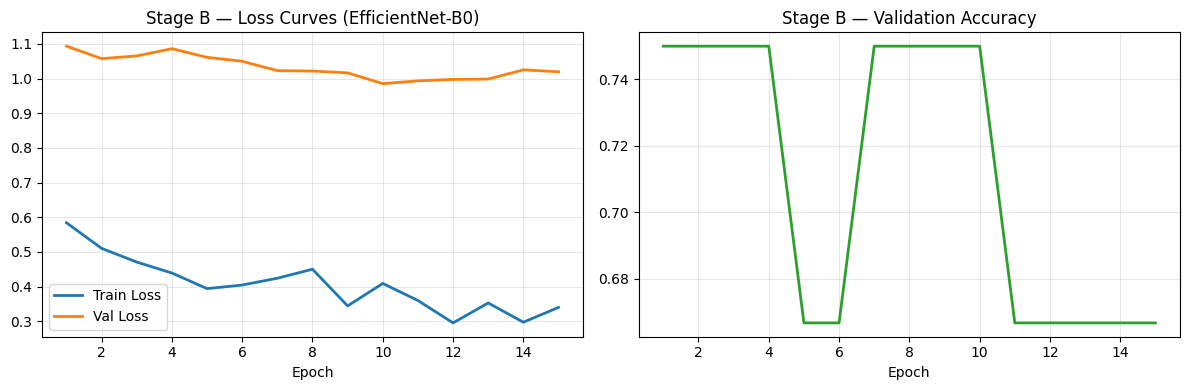

In [25]:
# Cell 9 — Stage B Training & Validation Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_b = range(1, len(history_b['train_loss']) + 1)
axes[0].plot(epochs_b, history_b['train_loss'], label='Train Loss', color='tab:blue', lw=2)
axes[0].plot(epochs_b, history_b['val_loss'],   label='Val Loss',   color='tab:orange', lw=2)
axes[0].set_title('Stage B — Loss Curves (EfficientNet-B0)'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_b, history_b['val_acc'], color='tab:green', lw=2)
axes[1].set_title('Stage B — Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(output_dir / 'location_efficientnet_stage_b_curves.png', dpi=200); plt.show()


=== Location EfficientNet-B0 — Validation Classification Metrics ===
Overall Accuracy    : 0.7500  (75.00%)
Macro F1 Score      : 0.6914
Weighted F1 Score   : 0.8524
Macro Precision     : 0.8000
Macro Recall        : 0.6167
-------------------------------------------------------------------

=== Per-Class Classification Report ===
 Class ID    Part Name Precision Recall F1-Score  Support
        0     headlamp    1.0000 0.7500   0.8571        4
        1 front_bumper    1.0000 0.6667   0.8000        3
        2         hood    0.0000 0.0000   0.0000        0
        3         door    1.0000 1.0000   1.0000        2
        4  rear_bumper    1.0000 0.6667   0.8000        3

Metrics saved to JSON: /content/NPN-Car-Insurance/ml/results/location/location_efficientnet_metrics.json


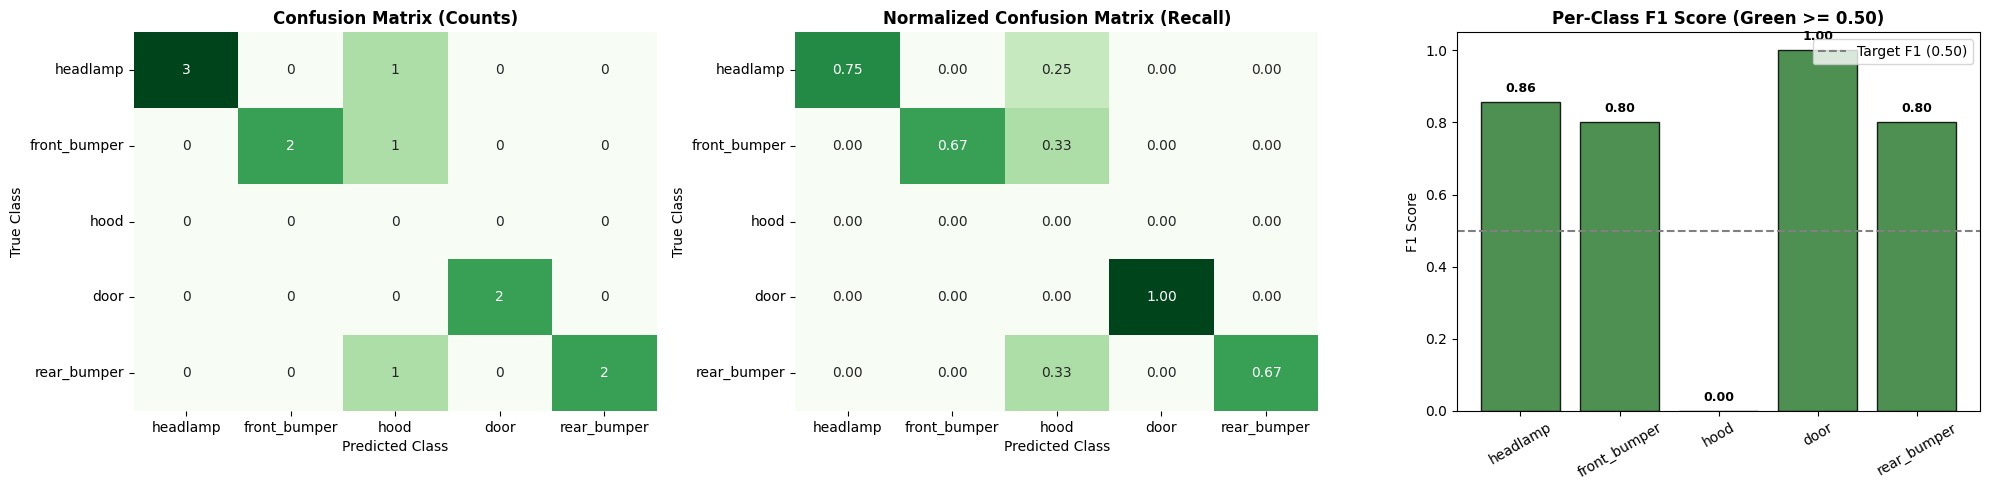

Evaluation plots saved: /content/NPN-Car-Insurance/ml/results/location/location_efficientnet_val_cm.png


In [26]:
# Cell 10 — Comprehensive Validation Classification Metrics & Analysis
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

model = model.to(device)
model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))
model = model.to(device)
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())
        all_probs.extend(probs)

labels_list = list(range(len(LOCATION_CLASSES)))

# 1. Global Summary Metrics
accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, labels=labels_list, average='macro', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, labels=labels_list, average='weighted', zero_division=0)
macro_prec = precision_score(all_labels, all_preds, labels=labels_list, average='macro', zero_division=0)
macro_rec = recall_score(all_labels, all_preds, labels=labels_list, average='macro', zero_division=0)

print('===================================================================')
print('=== Location EfficientNet-B0 — Validation Classification Metrics ===')
print('===================================================================')
print(f'Overall Accuracy    : {accuracy:6.4f}  ({accuracy*100:5.2f}%)')
print(f'Macro F1 Score      : {macro_f1:6.4f}')
print(f'Weighted F1 Score   : {weighted_f1:6.4f}')
print(f'Macro Precision     : {macro_prec:6.4f}')
print(f'Macro Recall        : {macro_rec:6.4f}')
print('-------------------------------------------------------------------')

# 2. Per-Class Metrics Table
report_dict = classification_report(
    all_labels,
    all_preds,
    labels=labels_list,
    target_names=LOCATION_CLASSES,
    output_dict=True,
    zero_division=0,
)

per_class_rows = []
for cid, cname in enumerate(LOCATION_CLASSES):
    metrics = report_dict.get(cname, {})
    per_class_rows.append({
        'Class ID': cid,
        'Part Name': cname,
        'Precision': metrics.get('precision', 0.0),
        'Recall': metrics.get('recall', 0.0),
        'F1-Score': metrics.get('f1-score', 0.0),
        'Support': int(metrics.get('support', 0)),
    })

metrics_df = pd.DataFrame(per_class_rows)
print('\n=== Per-Class Classification Report ===')
print(metrics_df.to_string(index=False, formatters={
    'Precision': '{:.4f}'.format,
    'Recall': '{:.4f}'.format,
    'F1-Score': '{:.4f}'.format,
}))

# 3. Save Metrics JSON Artifact
metrics_payload = {
    'model': 'EfficientNet-B0',
    'accuracy': float(accuracy),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'macro_precision': float(macro_prec),
    'macro_recall': float(macro_rec),
    'per_class': {row['Part Name']: {
        'precision': float(row['Precision']),
        'recall': float(row['Recall']),
        'f1': float(row['F1-Score']),
        'support': int(row['Support']),
    } for row in per_class_rows}
}
metrics_json_path = output_dir / 'location_efficientnet_metrics.json'
with open(metrics_json_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_payload, f, indent=2)
print(f'\nMetrics saved to JSON: {metrics_json_path}')

# 4. Visualizations: Side-by-Side Confusion Matrix (Counts & Normalized) + Per-Class F1
cm = confusion_matrix(all_labels, all_preds, labels=labels_list)
cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (a) Absolute Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=LOCATION_CLASSES, yticklabels=LOCATION_CLASSES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')

# (b) Normalized Confusion Matrix (Recall per class)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', cbar=False,
            xticklabels=LOCATION_CLASSES, yticklabels=LOCATION_CLASSES, ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix (Recall)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')

# (c) Per-Class F1 Score Bar Chart
colors = ['#2e7d32' if f1 >= 0.5 else '#d9534f' for f1 in metrics_df['F1-Score']]
bars = axes[2].bar(metrics_df['Part Name'], metrics_df['F1-Score'], color=colors, edgecolor='black', alpha=0.85)
axes[2].axhline(0.5, color='gray', linestyle='--', label='Target F1 (0.50)')
axes[2].set_ylim(0, 1.05)
axes[2].set_title('Per-Class F1 Score (Green >= 0.50)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('F1 Score')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(loc='upper right')
for bar in bars:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
cm_plot_path = output_dir / 'location_efficientnet_val_cm.png'
plt.savefig(cm_plot_path, dpi=200)
plt.show()
print(f'Evaluation plots saved: {cm_plot_path}')


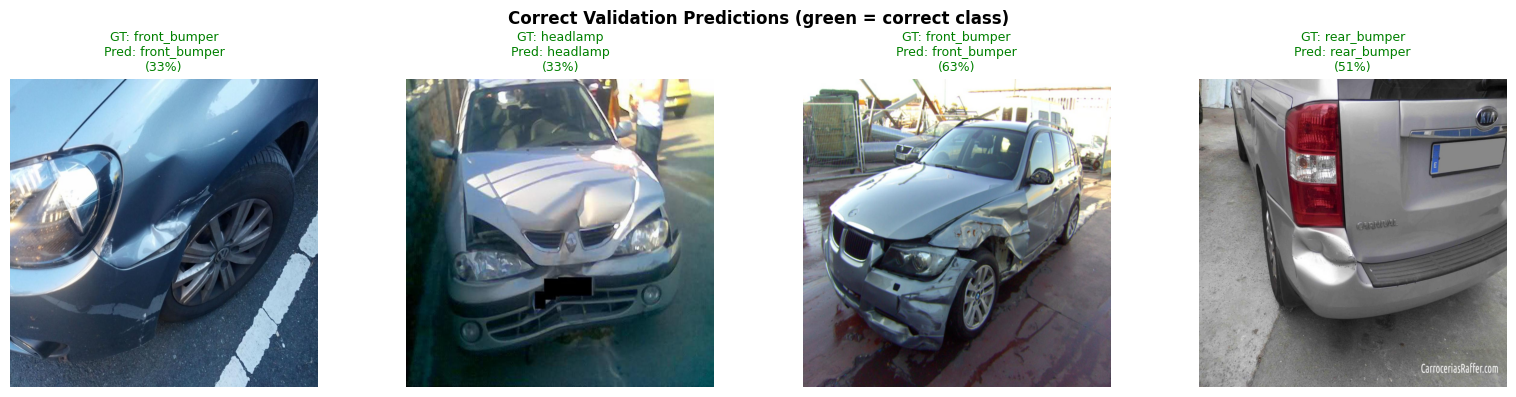

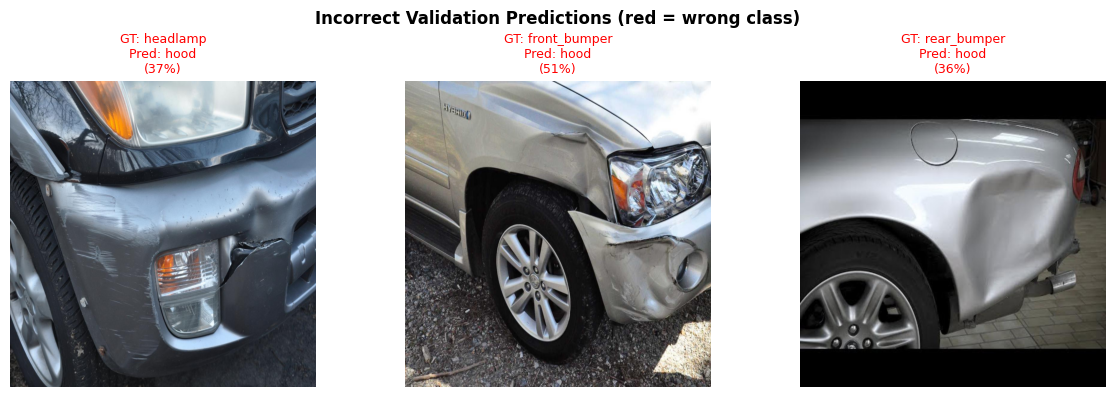

In [27]:
# Cell 11 — Visual Inspection: Correct and Incorrect Validation Predictions
from claimvision_ml.location.inference import classify_location

model = model.to(device)
model.eval()
correct_examples, wrong_examples = [], []
for full_path, label_id in val_ds.samples[:20]:
    label_name = LOCATION_CLASSES[label_id]
    result = classify_location(full_path, model, model_type='efficientnet', device=device)
    entry = (full_path, label_name, result.class_name, result.confidence)
    (correct_examples if result.class_name == label_name else wrong_examples).append(entry)

def show_examples(examples, title, max_n=4):
    if not examples: print(f'No {title.lower()} examples.'); return
    n = min(max_n, len(examples))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, (fpath, gt, pred, conf) in zip(axes, examples[:n]):
        img = cv2.imread(str(fpath))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        color = 'green' if gt == pred else 'red'
        ax.set_title(f'GT: {gt}\nPred: {pred}\n({conf:.0%})', color=color, fontsize=9); ax.axis('off')
    plt.suptitle(title, fontsize=12, fontweight='bold'); plt.tight_layout(); plt.show()

show_examples(correct_examples, 'Correct Validation Predictions (green = correct class)')
show_examples(wrong_examples,   'Incorrect Validation Predictions (red = wrong class)')


In [28]:
# Cell 12 — Error Analysis
print('=== Location EfficientNet-B0 — Qualitative Error Modes ===')
print()
print('Same error categories expected as MobileNetV2 (small dataset size):')
print('1. Front vs. rear bumper confusion — similar shape profile.')
print('2. Hood vs. front bumper on front-end collision images.')
print('3. Small headlamp area dominated by other parts in the frame.')
print()
print('EfficientNet-B0 advantage: compound scaling may better capture fine')
print('structural features (reflectors, grille patterns) that distinguish parts.')
print()
print('Results for comparison stored in: ml/results/location/')


=== Location EfficientNet-B0 — Qualitative Error Modes ===

Same error categories expected as MobileNetV2 (small dataset size):
1. Front vs. rear bumper confusion — similar shape profile.
2. Hood vs. front bumper on front-end collision images.
3. Small headlamp area dominated by other parts in the frame.

EfficientNet-B0 advantage: compound scaling may better capture fine
structural features (reflectors, grille patterns) that distinguish parts.

Results for comparison stored in: ml/results/location/


=== HELD-OUT TEST SET FORWARD INFERENCE ===
NOTE: The COCO test split contains NO ground-truth labels.
Running purely in forward-inference mode to generate qualitative visual predictions.

Found 8 held-out unannotated test images.

  [1] 11.jpg         : Pred = door           (63.9%) | Alt: front_bumper(19%), rear_bumper(13%)
  [2] 12.jpg         : Pred = door           (85.0%) | Alt: front_bumper(6%), headlamp(5%)
  [3] 28.jpg         : Pred = headlamp       (74.4%) | Alt: front_bumper(18%), rear_bumper(4%)
  [4] 45.jpg         : Pred = front_bumper   (37.6%) | Alt: door(26%), rear_bumper(26%)
  [5] 60.jpg         : Pred = front_bumper   (32.7%) | Alt: hood(24%), door(19%)
  [6] 66.jpg         : Pred = door           (82.9%) | Alt: rear_bumper(7%), front_bumper(6%)
  [7] 67.jpg         : Pred = front_bumper   (39.2%) | Alt: door(29%), rear_bumper(18%)
  [8] 72.jpg         : Pred = door           (43.7%) | Alt: hood(37%), rear_bumper(8%)


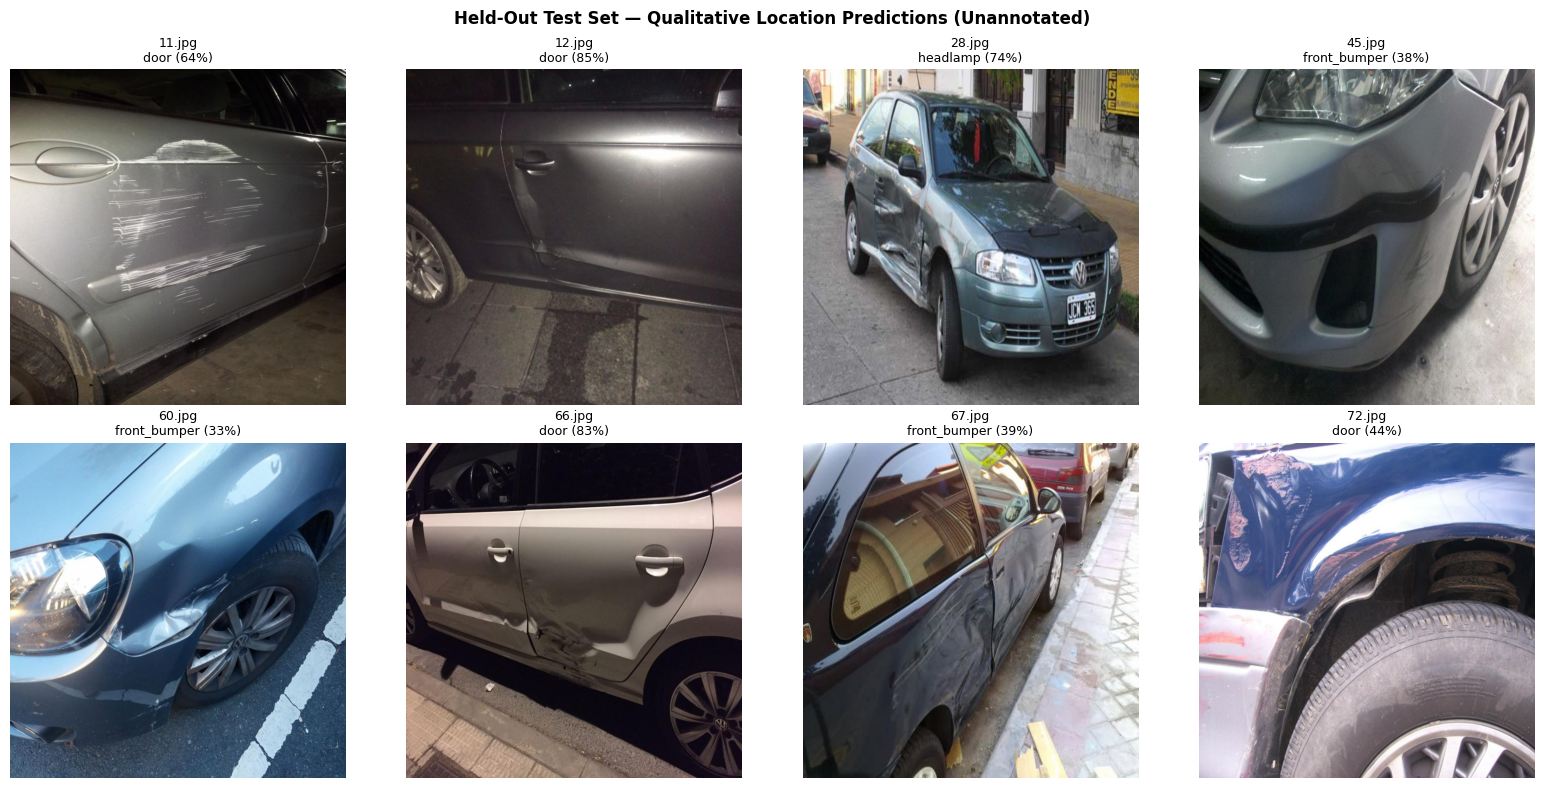


Test predictions plot saved: /content/NPN-Car-Insurance/ml/results/location/location_efficientnet_test_predictions.png


In [29]:
# Cell 13 — Held-Out Test Set Forward Inference (unannotated test split)
print('=== HELD-OUT TEST SET FORWARD INFERENCE ===')
print('NOTE: The COCO test split contains NO ground-truth labels.')
print('Running purely in forward-inference mode to generate qualitative visual predictions.\n')

model = model.to(device)
model.eval()

test_img_dir = RAW_DIR / 'test'
test_images = sorted([f for f in test_img_dir.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]) if test_img_dir.exists() else []
print(f'Found {len(test_images)} held-out unannotated test images.\n')

if test_images:
    n_display = min(8, len(test_images))
    rows = (n_display + 3) // 4
    fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for idx, img_path in enumerate(test_images[:n_display]):
        result = classify_location(img_path, model, model_type='efficientnet', device=device)
        top2_alt = ', '.join(f'{cls}({p:.0%})' for cls, p in result.top3[1:3])
        print(f'  [{idx+1}] {img_path.name:<15}: Pred = {result.class_name:<14} ({result.confidence:5.1%}) | Alt: {top2_alt}')
        img = cv2.imread(str(img_path))
        if img is not None:
            axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[idx].set_title(f'{img_path.name}\n{result.class_name} ({result.confidence:.0%})', fontsize=9)
            axes[idx].axis('off')

    for ax in axes[n_display:]:
        ax.axis('off')

    plt.suptitle('Held-Out Test Set — Qualitative Location Predictions (Unannotated)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    test_fig_path = output_dir / 'location_efficientnet_test_predictions.png'
    plt.savefig(test_fig_path, dpi=200)
    plt.show()
    print(f'\nTest predictions plot saved: {test_fig_path}')


In [30]:
# Cell 14 — Inference Latency & Model Size
sample_img = test_images[0] if test_images else val_ds.samples[0][0]
latency_ms = model.measure_cpu_latency(sample_img, num_runs=15)
model = model.to(device)
ckpt_size_mb = best_ckpt.stat().st_size / (1024 * 1024) if best_ckpt.exists() else 20.0
print(f'Architecture   : EfficientNet-B0 (5 location classes)')
print(f'CPU Latency    : {latency_ms:.2f} ms/image')
print(f'Model Size     : {ckpt_size_mb:.2f} MB')
assert latency_ms < 250.0, f'Latency {latency_ms:.2f} ms exceeds acceptable limit'
print('PASS: Latency within acceptable range.')


Architecture   : EfficientNet-B0 (5 location classes)
CPU Latency    : 36.44 ms/image
Model Size     : 16.21 MB
PASS: Latency within acceptable range.


In [31]:
# Cell 15 — Export artifacts (PyTorch + ONNX)
import shutil
from claimvision_ml.location.efficientnet import build_location_efficientnet
from claimvision_ml.location.inference import export_location_onnx

models_dir = REPO_ROOT / 'artifacts' / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

pt_dst = models_dir / 'location_efficientnet.pt'
shutil.copy2(str(best_ckpt), str(pt_dst)); print(f'PyTorch: {pt_dst}')

export_model = build_location_efficientnet(dropout=0.3, num_classes=5, pretrained=False)
export_model.load_state_dict(torch.load(best_ckpt, map_location='cpu', weights_only=True))
export_model.eval().cpu()
onnx_path = export_location_onnx(export_model, models_dir / 'location_efficientnet.onnx')
print(f'ONNX   : {onnx_path} ({onnx_path.stat().st_size / 1024 / 1024:.2f} MB)')


/content/NPN-Car-Insurance/ml/src/claimvision_ml/location/inference.py:340: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0922 16:19:56.953000 4197 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


PyTorch: /content/NPN-Car-Insurance/artifacts/models/location_efficientnet.pt
[torch.onnx] Obtain model graph for `LocationEfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LocationEfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: /project/onnx/version_converter/adapters/axes_input_to_attribute.h:55: 

[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX   : /content/NPN-Car-Insurance/artifacts/models/location_efficientnet.onnx (0.60 MB)


In [32]:
# Cell 16 — Reproducibility Record
import hashlib, platform, datetime

def sha256_of(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''): h.update(chunk)
    return h.hexdigest()

print('=== Reproducibility Record ===')
print(f'Python  : {platform.python_version()}  |  Seed: {SEED}')
print(f'Date    : {datetime.datetime.now().isoformat()}')
import torchvision, timm
print(f'torch   : {torch.__version__} | torchvision: {torchvision.__version__} | timm: {timm.__version__}')
if best_ckpt.exists(): print(f'SHA256  : {sha256_of(best_ckpt)}')


=== Reproducibility Record ===
Python  : 3.13.15  |  Seed: 42
Date    : 2026-09-22T16:20:04.107249
torch   : 2.11.0+cu128 | torchvision: 0.26.0+cu128 | timm: 1.0.29
SHA256  : fe1b0da6364afeb24fb6cf330cbae03bd87c5df5fd7bbc102536d4076a29b5a2


## Go / No-Go Protocol — LOC-EFF-001

| Condition | Threshold | Decision |
|---|---|---|
| Val Accuracy ≥ 0.50 | ≥ 50 % | Proceed to comparison Notebook 15 |
| Val Accuracy 0.30–0.50 | 30–50 % | Experimental — compare with MobileNetV2 |
| Val Accuracy < 0.30 | < 30 % | No-Go — chance level; do not use in demo |

Compare directly with Notebook 13 (MobileNetV2) results in Notebook 15.
